# Previsão de Evasão de Clientes - Telecom X


## Contexto do Projeto
Dando continuidade à análise exploratória realizada na Fase 1, a Telecom X avança para a etapa de inteligência preditiva. Com os padrões de evasão já identificados, este projeto aplica Machine Learning para prever quais clientes têm maior probabilidade de cancelar seus serviços, permitindo que a empresa aja de forma proativa na retenção.

## Objetivo
Desenvolver um pipeline de modelagem preditiva capaz de classificar clientes em risco de evasão, com base em suas características e comportamento. Os modelos gerados servirão como base para estratégias de retenção orientadas por dados.

## Como o projeto foi construído (Pipeline de Machine Learning)
O desenvolvimento seguiu as etapas clássicas de um pipeline de ML:

1. **Pré-processamento:** Os dados provenientes da Fase 1 passaram por encoding de variáveis categóricas, tratamento de valores ausentes e normalização das variáveis numéricas, preparando-os para os algoritmos de aprendizado.
2. **Seleção de Variáveis:** Foram aplicadas técnicas de análise de correlação para identificar as features com maior poder preditivo e eliminar redundâncias, tornando os modelos mais eficientes.
3. **Modelagem:** Dois ou mais algoritmos de classificação foram treinados e comparados, buscando o melhor equilíbrio entre desempenho e interpretabilidade.
4. **Avaliação:** Os modelos foram mensurados com métricas adequadas para problemas de classificação com dados desbalanceados, como Acurácia, Precisão, Recall, F1-Score e AUC-ROC.
5. **Interpretação e Conclusão Estratégica:** Os resultados foram traduzidos em insights acionáveis, destacando os principais fatores que influenciam a decisão de cancelamento.

## O que foi praticado
- Pré-processamento de dados para Machine Learning (encoding, normalização, balanceamento).
- Análise de correlação e seleção de features relevantes.
- Construção e comparação de modelos preditivos de classificação.
- Avaliação de desempenho com métricas adequadas ao contexto do negócio.
- Interpretação da importância das variáveis nos modelos.
- Comunicação técnica com foco em decisão estratégica.

## Ferramentas
Python (Pandas, Scikit-learn, Matplotlib, Seaborn).

# 🛠️ Preparação dos Dados

## Extração do Arquivo Tratado

In [5]:
# Cole o link raw copiado do GitHub dentro das aspas abaixo
url_github = 'https://raw.githubusercontent.com/taniamara13/Telecom-X-2---Predi-o-de-Churn/refs/heads/main/TelecomX_dados_tratados.csv'

df = pd.read_csv(url_github)
display(df.head())

,ID_Cliente,Cancelamento,Genero,Idoso,Tem_Parceiro,Tem_Dependentes,Meses_Contrato,Servico_Telefone,Multiplas_Linhas,Serviço_Internet,...,Protecao_Dispositivo,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Tipo_Contrato,Fatura_Digital,Forma_Pagamento,Cobranca_Mensal,Cobranca_Total,Cobranca_Diaria
0,0002-ORFBO,0,0,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,1,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,1,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,1,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,0,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80


## Remoção de Colunas Irrelevantes

### Etapa 1 — Remoção de Identificadores Únicos
Vamos remover a coluna ID_Cliente pois ela representa apenas um identificador único de cada registro, sem nenhum poder preditivo para o modelo.

In [6]:
# Removendo a coluna ID_Cliente
df = df.drop(columns=['ID_Cliente'])
df.head()

,Cancelamento,Genero,Idoso,Tem_Parceiro,Tem_Dependentes,Meses_Contrato,Servico_Telefone,Multiplas_Linhas,Serviço_Internet,Seguranca_Online,...,Protecao_Dispositivo,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Tipo_Contrato,Fatura_Digital,Forma_Pagamento,Cobranca_Mensal,Cobranca_Total,Cobranca_Diaria
0,0,0,0,1,1,9,1,0,DSL,0,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.19
1,0,1,0,0,0,9,1,1,DSL,0,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,1,1,0,0,0,4,1,0,Fiber optic,0,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,1,1,1,1,0,13,1,0,Fiber optic,0,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,1,0,1,1,0,3,1,0,Fiber optic,0,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80


### Etapa 2 — Análise de Variância Zero
Vamos identificar colunas onde quase todos os registros possuem o mesmo valor, pois essas colunas não ajudam o modelo a discriminar padrões. Nenhuma coluna ultrapassa o limiar de 95% de dominância

In [7]:
# Verificando variância zero — colunas onde um único valor domina acima de 95%
low_variance = [col for col in df.columns if df[col].value_counts(normalize=True).iloc[0] > 0.95]

low_variance

[]

### Etapa 3 — Análise de Multicolinearidade
Vamos identificar colunas numericamente muito correlacionadas entre si, pois guardar informação redundante pode prejudicar modelos lineares e inflar a importância de certas variáveis.

#### Parte 1: Matriz de Correlação + Heatmap

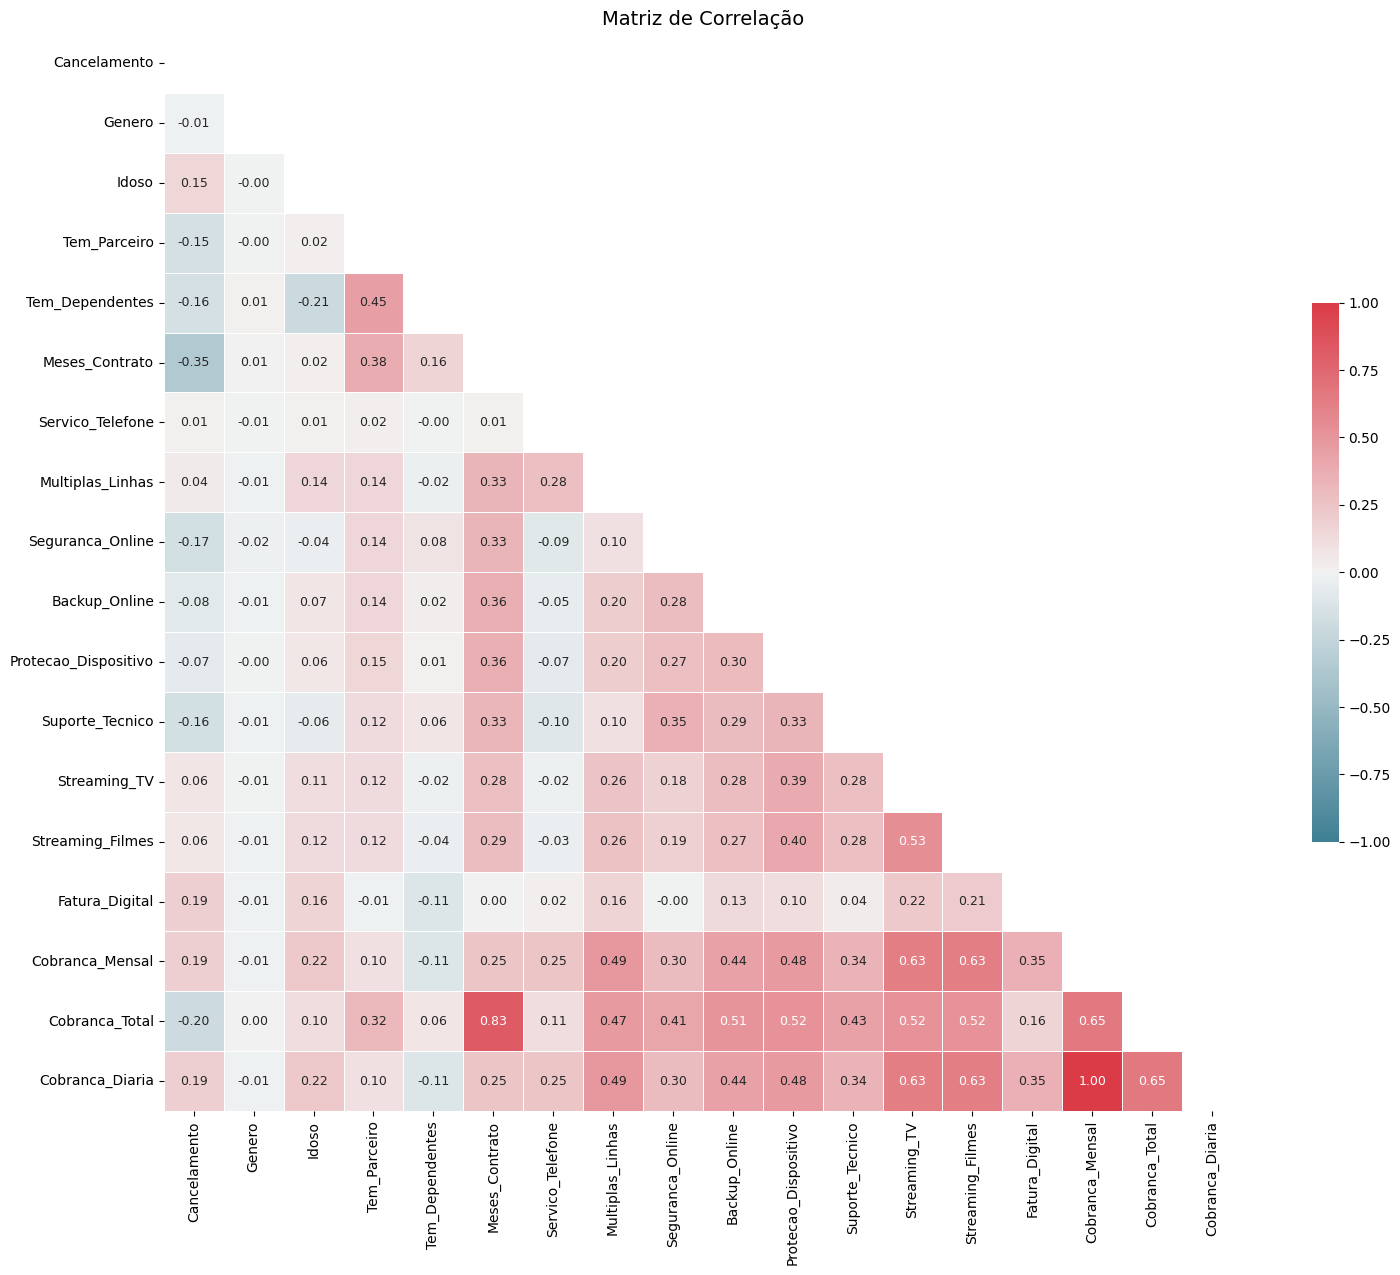

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()

mascara = np.zeros_like(corr, dtype=bool)
mascara[np.triu_indices_from(mascara)] = True

f, ax = plt.subplots(figsize=(18, 14))

cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(corr, mask=mascara, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, annot=True, fmt='.2f',
            annot_kws={"size": 9}, cbar_kws={"shrink": .5})

plt.title('Matriz de Correlação', fontsize=14)
plt.show()

#### Parte 2: VIF (Variance Inflation Factor)

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

explicativas = df.select_dtypes(include='number').drop(columns=['Cancelamento']).columns.tolist()

vif = pd.DataFrame()
vif['Variável'] = explicativas
vif['VIF'] = [variance_inflation_factor(df[explicativas].values, i) for i in range(len(explicativas))]

vif.sort_values('VIF', ascending=False)

,Variável,VIF
14,Cobranca_Mensal,650128.149300
16,Cobranca_Diaria,649898.209518
15,Cobranca_Total,13.986603
4,Meses_Contrato,10.932054
5,Servico_Telefone,10.372369
12,Streaming_Filmes,3.128150
11,Streaming_TV,3.097575
13,Fatura_Digital,2.851939
2,Tem_Parceiro,2.819649
6,Multiplas_Linhas,2.586859


#### Parte 3 — Remoção de Variáveis Redundantes
Vamos remover Cobranca_Diaria pois é derivada diretamente de Cobranca_Mensal, carregando a mesma informação em escala diferente.

In [10]:
# Removendo coluna redundante
df = df.drop(columns=['Cobranca_Diaria'])
df.head()

,Cancelamento,Genero,Idoso,Tem_Parceiro,Tem_Dependentes,Meses_Contrato,Servico_Telefone,Multiplas_Linhas,Serviço_Internet,Seguranca_Online,Backup_Online,Protecao_Dispositivo,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Tipo_Contrato,Fatura_Digital,Forma_Pagamento,Cobranca_Mensal,Cobranca_Total
0,0,0,0,1,1,9,1,0,DSL,0,1,0,1,1,0,One year,1,Mailed check,65.6,593.30
1,0,1,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40
2,1,1,0,0,0,4,1,0,Fiber optic,0,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85
3,1,1,1,1,0,13,1,0,Fiber optic,0,1,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85
4,1,0,1,1,0,3,1,0,Fiber optic,0,0,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40


#### EXTRA - Análise de Relevância das Variáveis Categóricas (Qui-quadrado)



A matriz de correlação de Pearson, gerada anteriormente, avalia a relação entre
variáveis **numéricas** e o target `Cancelamento`. No entanto, o dataset possui
três variáveis categóricas que não foram contempladas por essa análise:
`Serviço_Internet`, `Tipo_Contrato` e `Forma_Pagamento`.

Para avaliar a relevância dessas variáveis, aplicamos o **teste Qui-quadrado (χ²)**,
que mede se existe dependência estatística entre cada variável categórica e o target.

- **p-value < 0.05** → variável é estatisticamente significativa → mantemos
- **p-value ≥ 0.05** → variável não contribui com informação relevante → removemos

Esta etapa deve ser realizada **antes do encoding**, pois após a transformação as
categorias se tornam colunas binárias e perdemos a capacidade de avaliar cada
variável categórica como um todo.

In [11]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

# Variáveis categóricas a testar
colunas_categoricas = ['Serviço_Internet', 'Tipo_Contrato', 'Forma_Pagamento']

# Criar cópia para não alterar o df original
df_chi = df.copy()
df_chi['Cancelamento'] = df_chi['Cancelamento'].astype(int)

# Aplicar Label Encoding temporário apenas para o teste
le = LabelEncoder()
df_chi_encoded = df_chi[colunas_categoricas].apply(le.fit_transform)

# Aplicar teste Qui-quadrado
chi_scores, p_values = chi2(df_chi_encoded, df_chi['Cancelamento'])

# Criar DataFrame com resultado
chi_df = pd.DataFrame({
    'Variável': colunas_categoricas,
    'Chi2 Score': chi_scores.round(2),
    'p-value': p_values.round(4)
}).sort_values(by='Chi2 Score', ascending=False)

display(chi_df)

# Separar significativas e não significativas
nao_significativas = chi_df[chi_df['p-value'] >= 0.05]['Variável'].tolist()

if nao_significativas:
    df = df.drop(columns=nao_significativas)
    print(f"\n❌ Colunas removidas por não serem significativas: {nao_significativas}")
else:
    print("\n✅ Todas as variáveis categóricas são estatisticamente significativas — nenhuma removida.")

,Variável,Chi2 Score,p-value
1,Tipo_Contrato,1111.76,0.0000
2,Forma_Pagamento,59.24,0.0000
0,Serviço_Internet,9.72,0.0018



✅ Todas as variáveis categóricas são estatisticamente significativas — nenhuma removida.


## Encoding

In [12]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

# Separar target e features
X = df.drop(columns=['Cancelamento'])
y = df['Cancelamento']

# Colunas categóricas do nosso dataset
colunas_categoricas = ['Serviço_Internet', 'Tipo_Contrato', 'Forma_Pagamento']

# Configuração do transformador
one_hot = make_column_transformer(
    (OneHotEncoder(drop='if_binary'), colunas_categoricas),
    remainder='passthrough',
    sparse_threshold=0
)

# Aplicação da transformação
X = one_hot.fit_transform(X)

# Visualizar o resultado
nomes_colunas = one_hot.get_feature_names_out()
pd.DataFrame(X, columns=nomes_colunas).head()

,onehotencoder__Serviço_Internet_DSL,onehotencoder__Serviço_Internet_Fiber optic,onehotencoder__Serviço_Internet_No,onehotencoder__Tipo_Contrato_Month-to-month,onehotencoder__Tipo_Contrato_One year,onehotencoder__Tipo_Contrato_Two year,onehotencoder__Forma_Pagamento_Bank transfer (automatic),onehotencoder__Forma_Pagamento_Credit card (automatic),onehotencoder__Forma_Pagamento_Electronic check,onehotencoder__Forma_Pagamento_Mailed check,...,remainder__Multiplas_Linhas,remainder__Seguranca_Online,remainder__Backup_Online,remainder__Protecao_Dispositivo,remainder__Suporte_Tecnico,remainder__Streaming_TV,remainder__Streaming_Filmes,remainder__Fatura_Digital,remainder__Cobranca_Mensal,remainder__Cobranca_Total
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,65.6,593.30
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,59.9,542.40
2,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,73.9,280.85
3,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,98.0,1237.85
4,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,83.9,267.40


## Verificação da Proporção de Evasão

In [13]:
# Cálculo da proporção de evasão (adicione estas linhas)
contagem = df['Cancelamento'].value_counts()
percentuais = (df['Cancelamento'].value_counts(normalize=True) * 100).round(1)
proporcao_df = contagem.to_frame(name='Contagem')


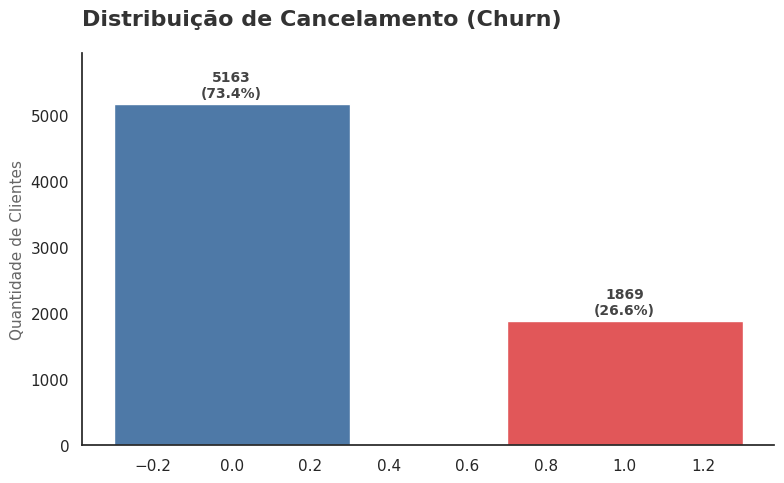

In [14]:
# Configuração de estilo e tipografia
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(8, 5))

# Definição da paleta de cores para as categorias
colors = ["#4e79a7", "#e15759"]

# Geração do gráfico de barras
bars = ax.bar(proporcao_df.index, proporcao_df['Contagem'], color=colors, width=0.6)

# Formatação e posicionamento dos rótulos de dados (Contagem e Porcentagem)
labels = [f'{int(cnt)}\n({perc}%)' for cnt, perc in zip(contagem, percentuais)]
ax.bar_label(bars, labels=labels, padding=3, fontsize=10, fontweight='bold', color='#444444')

# Configuração de títulos e identificação dos eixos
ax.set_title('Distribuição de Cancelamento (Churn)', fontsize=16, fontweight='bold', pad=20, loc='left', color='#333333')
ax.set_ylabel('Quantidade de Clientes', fontsize=11, color='#666666')
ax.set_xlabel('')

# Ajuste da escala do eixo Y para acomodação dos rótulos superiores
ax.set_ylim(0, proporcao_df['Contagem'].max() * 1.15)

# Remoção das molduras superior e direita (spines)
sns.despine()

plt.tight_layout()
plt.show()

## Balanceamento de Classes (opcional )

O dataset apresenta um desequilíbrio moderado entre as classes: 73,4% dos clientes
não cancelaram o serviço, enquanto 26,6% evadiram. Embora esse desequilíbrio não
seja severo — situações críticas costumam apresentar proporções como 95% vs 5% —
ele é suficiente para impactar modelos preditivos, que tendem a favorecer a classe
majoritária e prejudicar a detecção dos cancelamentos.

Técnicas como SMOTE (geração de exemplos sintéticos) ou undersampling/oversampling
podem ser aplicadas para corrigir esse desequilíbrio. No entanto, dado o nível
moderado observado, optou-se por uma abordagem mais simples e igualmente eficaz:
o uso do parâmetro class_weight='balanced' diretamente nos modelos preditivos.
Esse parâmetro instrui o algoritmo a penalizar mais os erros cometidos na classe
minoritária (cancelamentos), compensando o desequilíbrio sem a necessidade de
alterar ou gerar novos dados.

## Normalização ou Padronização (se necessário)

In [15]:
# Verificar as colunas numéricas e suas escalas
df[['Meses_Contrato', 'Cobranca_Mensal', 'Cobranca_Total']].describe()

,Meses_Contrato,Cobranca_Mensal,Cobranca_Total
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


In [16]:
from sklearn.preprocessing import StandardScaler

# Passo 1 — Encontrar índices automaticamente
colunas = list(one_hot.get_feature_names_out())
indices_numericos = [
    colunas.index('remainder__Meses_Contrato'),
    colunas.index('remainder__Cobranca_Mensal'),
    colunas.index('remainder__Cobranca_Total')
]
print("Índices encontrados:", indices_numericos)

# Passo 2 — Aplicar StandardScaler
scaler = StandardScaler()
X[:, indices_numericos] = scaler.fit_transform(X[:, indices_numericos])

# Passo 3 — Verificar resultado
pd.DataFrame(X, columns=one_hot.get_feature_names_out())[
    ['remainder__Meses_Contrato', 'remainder__Cobranca_Mensal', 'remainder__Cobranca_Total']
].head()

Índices encontrados: [14, 24, 25]


,remainder__Meses_Contrato,remainder__Cobranca_Mensal,remainder__Cobranca_Total
0,-0.954296,0.026652,-0.745607
1,-0.954296,-0.162819,-0.768063
2,-1.158016,0.302548,-0.883456
3,-0.791321,1.103642,-0.461240
4,-1.198760,0.634952,-0.889390


# 🎯 Correlação e Seleção de Variáveis

## Análise de Correlação

A matriz de correlação entre as variáveis numéricas já foi gerada na etapa anterior.
Agora, o foco é identificar quais variáveis têm maior **força de correlação** com
`Cancelamento`, independente da direção (positiva ou negativa).

Para isso, ordenamos pelo valor absoluto do coeficiente de correlação — as variáveis
no topo são as que mais influenciam a evasão. A cor indica a direção: vermelho para
correlação positiva (aumenta o risco) e azul para negativa (reduz o risco).

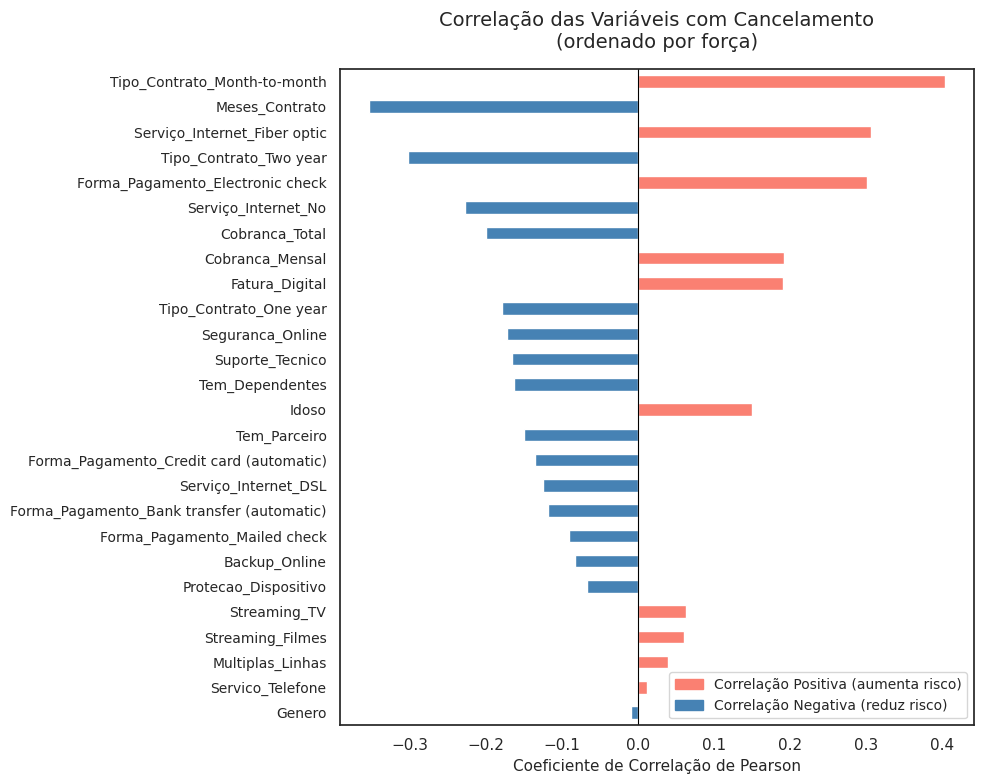

In [17]:
# Reconstruir DataFrame com os dados já processados
df_modelagem = pd.DataFrame(X, columns=nomes_colunas)
df_modelagem['Cancelamento'] = y.values

# Correlação com o target, ordenada pelo valor absoluto (força)
corr_target = df_modelagem.corr()['Cancelamento'].drop('Cancelamento')
corr_target = corr_target.reindex(corr_target.abs().sort_values().index)

# Renomear só o índice para exibição (sem alterar df_modelagem)
corr_target.index = (
    corr_target.index
    .str.replace('onehotencoder__', '', regex=False)
    .str.replace('remainder__', '', regex=False)
)

# Cores por direção
cores = ['salmon' if v > 0 else 'steelblue' for v in corr_target]

# ✅ Altura dinâmica: 0.4 por barra, mínimo 5, máximo 8
altura = max(5, min(8, len(corr_target) * 0.4))

fig, ax = plt.subplots(figsize=(10, altura))
corr_target.plot(kind='barh', color=cores, ax=ax, edgecolor='white')

ax.set_title('Correlação das Variáveis com Cancelamento\n(ordenado por força)', fontsize=14, pad=15)
ax.set_xlabel('Coeficiente de Correlação de Pearson', fontsize=11)
ax.axvline(0, color='black', linewidth=0.8)
ax.tick_params(axis='y', labelsize=10)

legenda = [
    Patch(color='salmon', label='Correlação Positiva (aumenta risco)'),
    Patch(color='steelblue', label='Correlação Negativa (reduz risco)')
]
ax.legend(handles=legenda, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

## Análises Direcionadas

O card sugere investigar variáveis específicas em relação à evasão usando
boxplots ou scatter plots. Com base no gráfico de correlação gerado anteriormente,
selecionamos as variáveis com maior força de correlação com `Cancelamento` e
as agrupamos por tipo, pois cada tipo exige um gráfico diferente:

- **Variáveis Contínuas** → Boxplot: mostram a distribuição dos valores
  separando clientes que cancelaram dos que não cancelaram
- **Variáveis Categóricas** → Gráfico de Barras: mostram a taxa de cancelamento
  dentro de cada categoria
- **Variáveis Binárias** → Gráfico de Barras: assim como as categóricas, mostram
  a taxa de cancelamento para cada valor (0 ou 1)

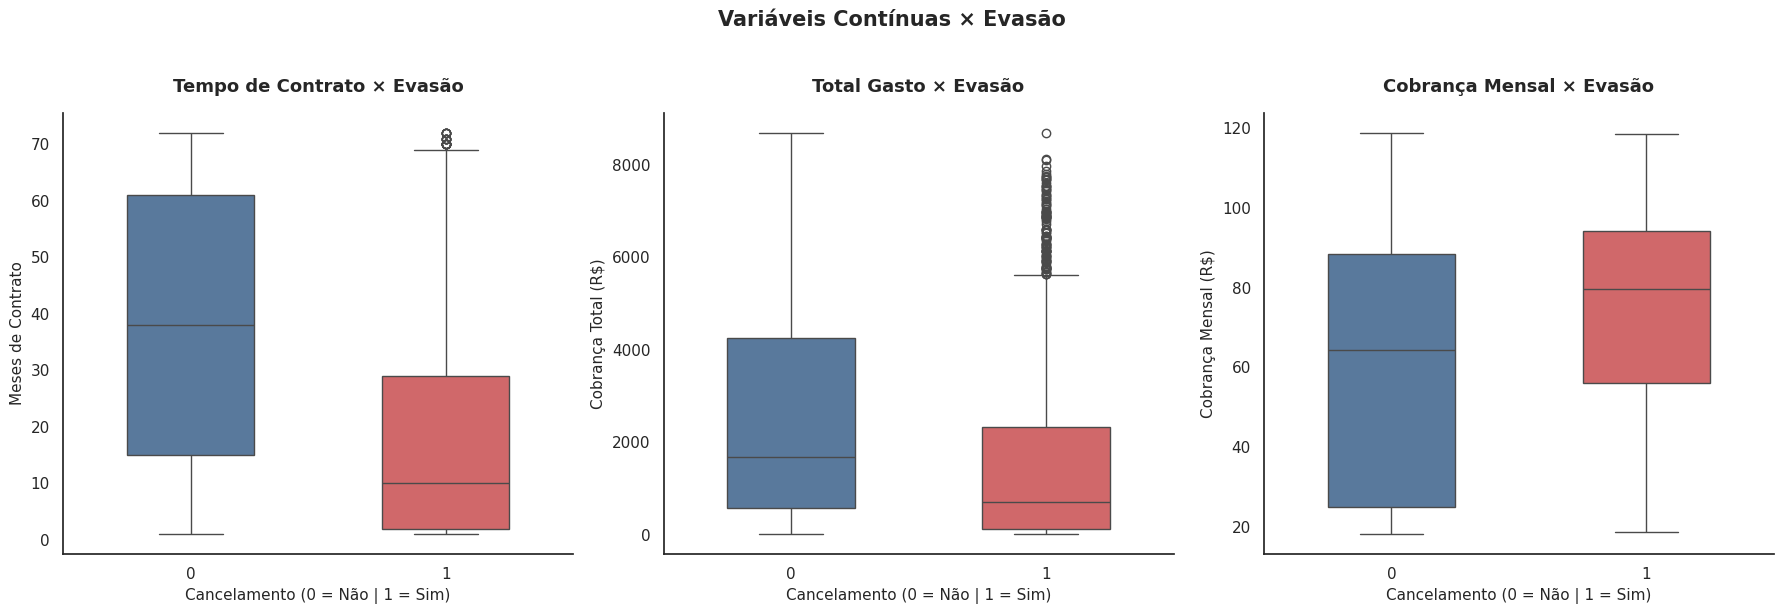

In [18]:
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Garantir que Cancelamento é inteiro
df['Cancelamento'] = df['Cancelamento'].astype(int)

# Gráfico 1 — Tempo de Contrato × Evasão
sns.boxplot(
    data=df, x='Cancelamento', y='Meses_Contrato',
    hue='Cancelamento',
    palette={0: '#4e79a7', 1: '#e15759'},
    width=0.5, ax=axes[0], legend=False
)
axes[0].set_title('Tempo de Contrato × Evasão', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Cancelamento (0 = Não | 1 = Sim)', fontsize=11)
axes[0].set_ylabel('Meses de Contrato', fontsize=11)
sns.despine(ax=axes[0])

# Gráfico 2 — Total Gasto × Evasão
sns.boxplot(
    data=df, x='Cancelamento', y='Cobranca_Total',
    hue='Cancelamento',
    palette={0: '#4e79a7', 1: '#e15759'},
    width=0.5, ax=axes[1], legend=False
)
axes[1].set_title('Total Gasto × Evasão', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Cancelamento (0 = Não | 1 = Sim)', fontsize=11)
axes[1].set_ylabel('Cobrança Total (R$)', fontsize=11)
sns.despine(ax=axes[1])

# Gráfico 3 — Cobrança Mensal × Evasão
sns.boxplot(
    data=df, x='Cancelamento', y='Cobranca_Mensal',
    hue='Cancelamento',
    palette={0: '#4e79a7', 1: '#e15759'},
    width=0.5, ax=axes[2], legend=False
)
axes[2].set_title('Cobrança Mensal × Evasão', fontsize=13, fontweight='bold', pad=15)
axes[2].set_xlabel('Cancelamento (0 = Não | 1 = Sim)', fontsize=11)
axes[2].set_ylabel('Cobrança Mensal (R$)', fontsize=11)
sns.despine(ax=axes[2])

plt.suptitle('Variáveis Contínuas × Evasão', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Análises Direcionadas — Variáveis Adicionais

O card sugere investigar **Tempo de Contrato** e **Total Gasto** como exemplos de análises direcionadas.
No entanto, ao observar o gráfico de correlação gerado na etapa anterior, três outras variáveis
apresentam força de correlação com `Cancelamento` igual ou superior às sugeridas:

- **Tipo_Contrato**: é a variável com **maior correlação absoluta** de todo o dataset.
  Contratos mensais (Month-to-month) concentram a grande maioria das evasões.
- **Serviço_Internet**: clientes com Fiber optic apresentam correlação positiva forte com o cancelamento,
  enquanto clientes sem internet apresentam correlação negativa — sugerindo perfis de risco bem distintos.
- **Forma_Pagamento**: o pagamento via Electronic check se destaca com correlação positiva relevante,
  possivelmente indicando um perfil de cliente menos fidelizado.

Por isso, optou-se por ampliar as análises direcionadas para incluir essas três variáveis,
tornando a investigação mais completa e alinhada com os dados observados.

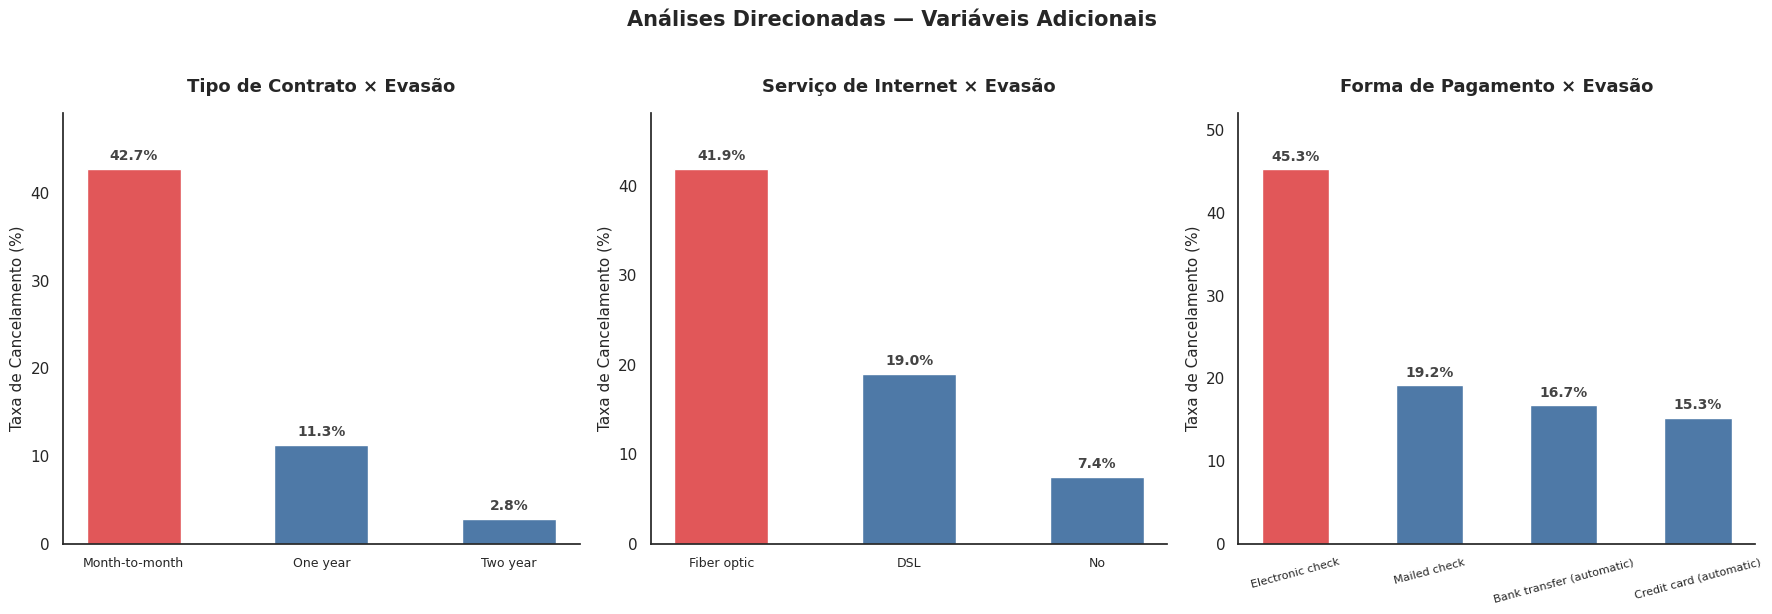

In [19]:
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Gráfico 1 — Tipo de Contrato × Evasão
taxa_contrato = df.groupby('Tipo_Contrato')['Cancelamento'].mean().sort_values(ascending=False) * 100
cores_contrato = ['#e15759' if v > 30 else '#4e79a7' for v in taxa_contrato]

axes[0].bar(taxa_contrato.index, taxa_contrato.values, color=cores_contrato, width=0.5, edgecolor='white')
for i, v in enumerate(taxa_contrato.values):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold', color='#444444')
axes[0].set_title('Tipo de Contrato × Evasão', fontsize=13, fontweight='bold', pad=15)
axes[0].set_ylabel('Taxa de Cancelamento (%)', fontsize=11)
axes[0].set_xlabel('')
axes[0].set_ylim(0, taxa_contrato.max() * 1.15)
axes[0].tick_params(axis='x', labelsize=9)
sns.despine(ax=axes[0])

# Gráfico 2 — Serviço de Internet × Evasão
taxa_internet = df.groupby('Serviço_Internet')['Cancelamento'].mean().sort_values(ascending=False) * 100
cores_internet = ['#e15759' if v > 30 else '#4e79a7' for v in taxa_internet]

axes[1].bar(taxa_internet.index, taxa_internet.values, color=cores_internet, width=0.5, edgecolor='white')
for i, v in enumerate(taxa_internet.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold', color='#444444')
axes[1].set_title('Serviço de Internet × Evasão', fontsize=13, fontweight='bold', pad=15)
axes[1].set_ylabel('Taxa de Cancelamento (%)', fontsize=11)
axes[1].set_xlabel('')
axes[1].set_ylim(0, taxa_internet.max() * 1.15)
axes[1].tick_params(axis='x', labelsize=9)
sns.despine(ax=axes[1])

# Gráfico 3 — Forma de Pagamento × Evasão
taxa_pagamento = df.groupby('Forma_Pagamento')['Cancelamento'].mean().sort_values(ascending=False) * 100
cores_pagamento = ['#e15759' if v > 30 else '#4e79a7' for v in taxa_pagamento]

axes[2].bar(taxa_pagamento.index, taxa_pagamento.values, color=cores_pagamento, width=0.5, edgecolor='white')
for i, v in enumerate(taxa_pagamento.values):
    axes[2].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold', color='#444444')
axes[2].set_title('Forma de Pagamento × Evasão', fontsize=13, fontweight='bold', pad=15)
axes[2].set_ylabel('Taxa de Cancelamento (%)', fontsize=11)
axes[2].set_xlabel('')
axes[2].set_ylim(0, taxa_pagamento.max() * 1.15)
axes[2].tick_params(axis='x', labelsize=8, rotation=15)
sns.despine(ax=axes[2])

plt.suptitle('Análises Direcionadas — Variáveis Adicionais', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Variáveis Binárias × Evasão

Duas variáveis binárias se destacaram no gráfico de correlação com força
moderada: `Fatura_Digital` e `Idoso`.

Apesar de serem representadas como 0 e 1, elas carregam informação relevante
sobre o perfil do cliente:

- **Fatura_Digital**: clientes que optam por fatura digital tendem a ter
  perfil mais digital e menos fidelizado, o que pode estar associado a maior
  facilidade de cancelamento
- **Idoso**: clientes idosos podem ter comportamento de consumo diferente,
  com menor ou maior propensão ao cancelamento

Para variáveis binárias, o gráfico de barras com taxa de cancelamento é o
mais adequado — ele mostra claramente a diferença de evasão entre os dois
grupos (0 e 1) de cada variável.

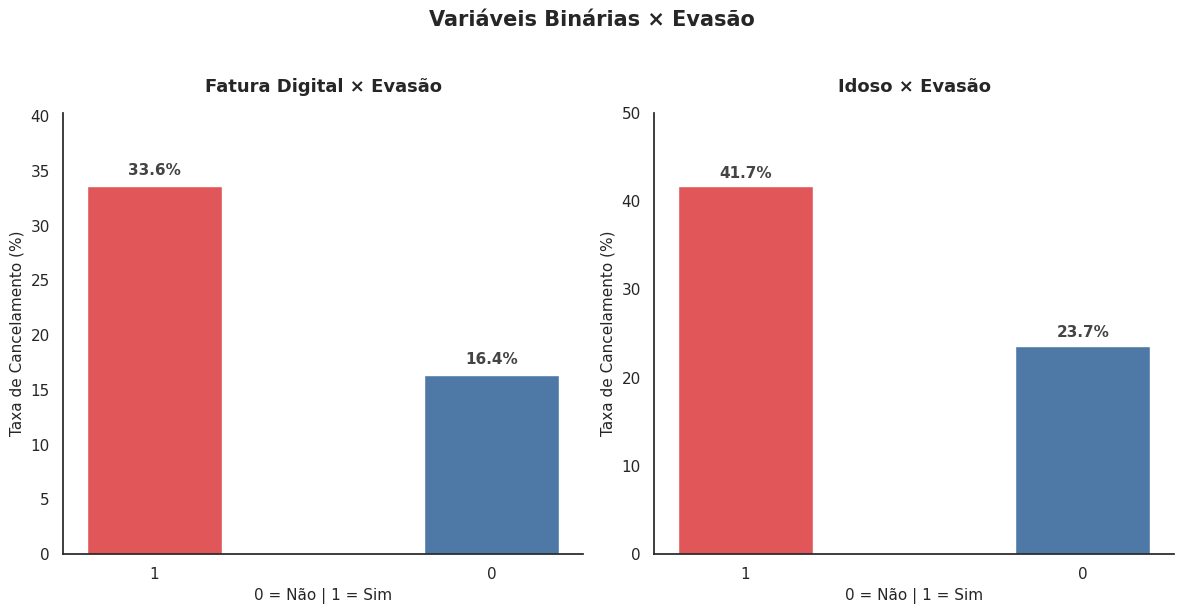

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, col, titulo in zip(axes,
    ['Fatura_Digital', 'Idoso'],
    ['Fatura Digital × Evasão', 'Idoso × Evasão']):

    taxa = df.groupby(col)['Cancelamento'].mean().sort_values(ascending=False) * 100
    cores = ['#e15759' if v > 30 else '#4e79a7' for v in taxa]

    ax.bar(taxa.index.astype(str), taxa.values, color=cores, width=0.4, edgecolor='white')
    for i, v in enumerate(taxa.values):
        ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=11,
                fontweight='bold', color='#444444')

    ax.set_title(titulo, fontsize=13, fontweight='bold', pad=15)
    ax.set_ylabel('Taxa de Cancelamento (%)', fontsize=11)
    ax.set_xlabel('0 = Não | 1 = Sim', fontsize=11)
    ax.set_ylim(0, taxa.max() * 1.2)
    sns.despine(ax=ax)

plt.suptitle('Variáveis Binárias × Evasão', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 🤖 Modelagem Preditiva

## Separação de Dados

Antes de treinar o modelo, dividimos o dataset em dois conjuntos:

- **Treino (80%)**: usado para o modelo aprender os padrões
- **Teste (20%)**: usado para avaliar o desempenho em dados nunca vistos

Com ~7.000 registros, a divisão 80/20 é a mais indicada — garante dados
suficientes para treino sem sacrificar a avaliação.

Utilizamos `stratify=y` para manter a proporção original de cancelamento
(26,6%) em ambos os conjuntos, evitando que o desbalanceamento distorça
a avaliação do modelo.

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Treino:  {X_train.shape[0]} registros ({X_train.shape[0]/X.shape[0]*100:.0f}%)")
print(f"Teste:   {X_test.shape[0]} registros ({X_test.shape[0]/X.shape[0]*100:.0f}%)")
print(f"\nProporção de cancelamento no treino: {y_train.mean()*100:.1f}%")
print(f"Proporção de cancelamento no teste:  {y_test.mean()*100:.1f}%")

Treino:  5625 registros (80%)
Teste:   1407 registros (20%)

Proporção de cancelamento no treino: 26.6%
Proporção de cancelamento no teste:  26.6%


## Criação de Modelos

Foram criados três modelos de classificação para prever a evasão de clientes,
cobrindo diferentes abordagens e complexidades:

**Modelo 1 — Regressão Logística**
Modelo linear e interpretável, usado como **baseline** para comparação.
Sensível à escala das variáveis, por isso **exige normalização** — já realizada
na etapa anterior. Utiliza `class_weight='balanced'` para compensar o
desbalanceamento entre clientes que cancelam (26,6%) e os que não cancelam (73,4%).

**Modelo 2 — Árvore de Decisão**
Modelo baseado em **regras de decisão** sequenciais — divide os dados em
grupos progressivamente mais puros. Interpretável e visual, permite entender
exatamente quais condições levam ao cancelamento. **Não exige normalização.**
Utiliza `class_weight='balanced'` para lidar com o desbalanceamento.

**Modelo 3 — Random Forest**
Conjunto de centenas de Árvores de Decisão treinadas em subamostras diferentes
dos dados — o resultado final é a votação da maioria. Mais robusto e preciso
que uma única árvore, pois reduz o overfitting. **Não exige normalização.**
Utiliza `class_weight='balanced'` para lidar com o desbalanceamento.

Modelo 1 — Regressão Logística

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("📊 Regressão Logística")
print(classification_report(y_test, y_pred_log))

📊 Regressão Logística
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1033
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.76      1407



Modelo 2 — Árvore de Decisão

In [23]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

print("🌿 Árvore de Decisão")
print(classification_report(y_test, y_pred_tree))

🌿 Árvore de Decisão
              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1033
           1       0.50      0.51      0.51       374

    accuracy                           0.74      1407
   macro avg       0.66      0.66      0.66      1407
weighted avg       0.74      0.74      0.74      1407



Modelo 3 — Random Forest

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("🌳 Random Forest")
print(classification_report(y_test, y_pred_rf))

🌳 Random Forest
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.65      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



## Avaliação dos Modelos

Para escolher o melhor modelo, avaliamos cada um com cinco métricas complementares.
Como nosso dataset é desbalanceado (26,6% cancela vs 73,4% não cancela), a
acurácia sozinha pode enganar — um modelo que sempre diz "não cancela" já teria
73,4% de acurácia sem aprender nada útil. Por isso analisamos o conjunto completo:

**Acurácia** — percentual de previsões corretas no total. Útil como referência
geral, mas insuficiente sozinha em datasets desbalanceados.

**Precisão (Precision)** — de todos os clientes que o modelo previu que cancelariam,
quantos realmente cancelaram? Alta precisão significa menos alarmes falsos.

**Recall** — de todos os clientes que realmente cancelaram, quantos o modelo
conseguiu detectar? Alto recall significa menos cancelamentos não detectados.

**F1-Score** — média harmônica entre Precisão e Recall. Métrica mais equilibrada
para problemas com desbalanceamento de classes.

**Matriz de Confusão** — fotografia completa dos erros do modelo, mostrando:
- **Verdadeiro Negativo (VN)**: não cancela e modelo disse não cancela ✅
- **Falso Positivo (FP)**: não cancela mas modelo disse cancela ❌
- **Falso Negativo (FN)**: cancela mas modelo disse não cancela ❌ (o mais custoso!)
- **Verdadeiro Positivo (VP)**: cancela e modelo disse cancela ✅

> 💡 Para evasão de clientes, priorizamos o **Recall** — é mais custoso deixar
> de detectar um cliente que vai cancelar do que oferecer retenção a quem ficaria.

**Métricas comparativas:**

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

modelos = {
    'Regressão Logística': y_pred_log,
    'Árvore de Decisão': y_pred_tree,
    'Random Forest': y_pred_rf
}

resultados = []
for nome, y_pred in modelos.items():
    resultados.append({
        'Modelo': nome,
        'Acurácia': accuracy_score(y_test, y_pred),
        'Precisão (cancela)': precision_score(y_test, y_pred),
        'Recall (cancela)': recall_score(y_test, y_pred),
        'F1-Score (cancela)': f1_score(y_test, y_pred)
    })

df_resultados = pd.DataFrame(resultados).set_index('Modelo').round(2)
display(df_resultados.style.highlight_max(color='lightgreen').highlight_min(color='#ffcccc'))

,Acurácia,Precisão (cancela),Recall (cancela),F1-Score (cancela)
Modelo,,,,
Regressão Logística,0.740000,0.510000,0.790000,0.620000
Árvore de Decisão,0.740000,0.500000,0.510000,0.510000
Random Forest,0.790000,0.650000,0.480000,0.550000


**Matrizes de Confusão:**

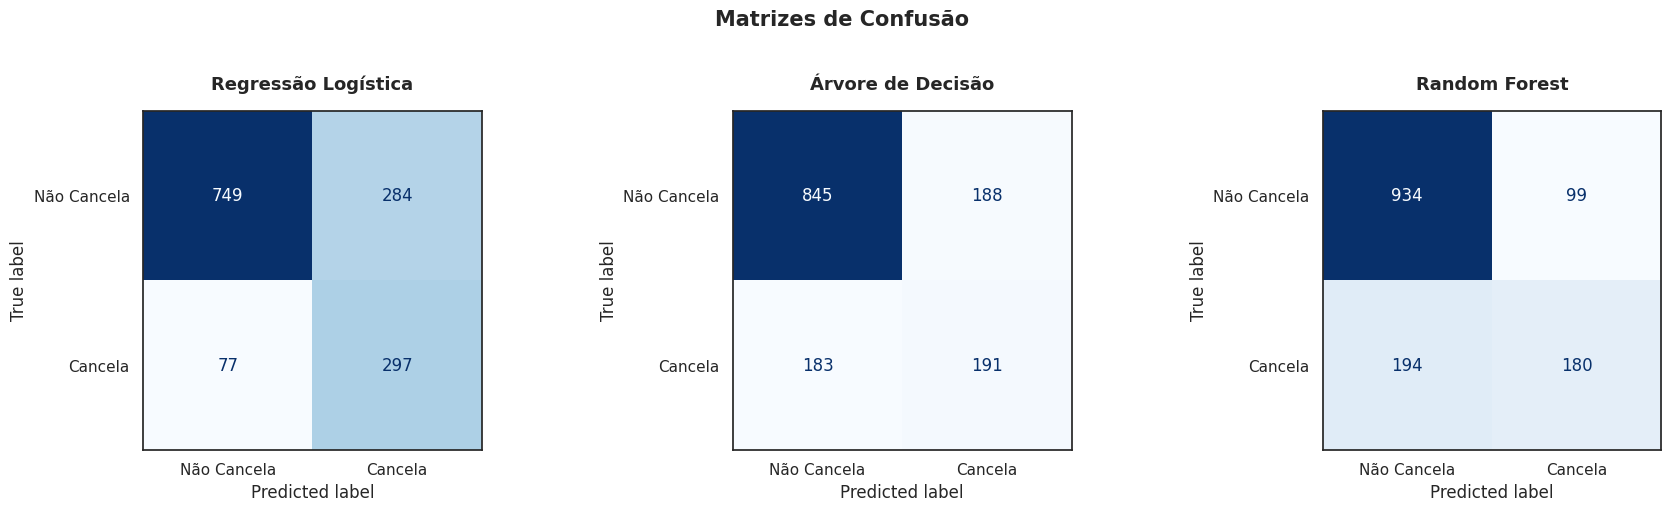

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nome, y_pred) in zip(axes, modelos.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não Cancela', 'Cancela'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nome, fontsize=13, fontweight='bold', pad=15)

plt.suptitle('Matrizes de Confusão', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [27]:
from sklearn.metrics import accuracy_score

print("=" * 55)
print("ANÁLISE CRÍTICA DOS MODELOS")
print("=" * 55)

for nome, y_pred in modelos.items():
    acc_treino = accuracy_score(
        y_train,
        (log_model if 'Log' in nome else tree_model if 'Árvore' in nome else rf_model).predict(X_train)
    )
    acc_teste = accuracy_score(y_test, y_pred)
    diff = acc_treino - acc_teste

    print(f"\n📊 {nome}")
    print(f"   Acurácia Treino : {acc_treino:.2%}")
    print(f"   Acurácia Teste  : {acc_teste:.2%}")
    print(f"   Diferença       : {diff:.2%}", end=" ")

    if diff > 0.10:
        print("⚠️  OVERFITTING — modelo decorou o treino")
    elif acc_teste < 0.70:
        print("⚠️  UNDERFITTING — modelo muito simples")
    else:
        print("✅ Generalização adequada")

print("\n" + "=" * 55)
print(f"🏆 Melhor Recall (detectar cancelamentos):")
melhor = max(modelos, key=lambda m: recall_score(y_test, modelos[m]))
print(f"   {melhor}")
print(f"\n🏆 Melhor F1-Score (equilíbrio geral):")
melhor_f1 = max(modelos, key=lambda m: f1_score(y_test, modelos[m]))
print(f"   {melhor_f1}")
print("=" * 55)

ANÁLISE CRÍTICA DOS MODELOS

📊 Regressão Logística
   Acurácia Treino : 75.31%
   Acurácia Teste  : 74.34%
   Diferença       : 0.96% ✅ Generalização adequada

📊 Árvore de Decisão
   Acurácia Treino : 99.73%
   Acurácia Teste  : 73.63%
   Diferença       : 26.10% ⚠️  OVERFITTING — modelo decorou o treino

📊 Random Forest
   Acurácia Treino : 99.77%
   Acurácia Teste  : 79.18%
   Diferença       : 20.59% ⚠️  OVERFITTING — modelo decorou o treino

🏆 Melhor Recall (detectar cancelamentos):
   Regressão Logística

🏆 Melhor F1-Score (equilíbrio geral):
   Regressão Logística


## Análise Crítica dos Modelos



**Qual modelo teve o melhor desempenho?**

A **Regressão Logística** foi o modelo mais adequado para este problema:
- Melhor Recall (0.79) — detectou 297 dos 374 cancelamentos reais
- Melhor F1-Score (0.62) — melhor equilíbrio entre Precisão e Recall
- Sem overfitting — diferença de apenas 0.96% entre treino e teste

**Overfitting e Underfitting**

**Árvore de Decisão** e **Random Forest** apresentaram overfitting severo:
- Árvore de Decisão: 99.73% no treino vs 73.63% no teste (diferença de 26%)
- Random Forest: 99.77% no treino vs 79.18% no teste (diferença de 21%)

Ambos "decoraram" os dados de treino e perderam a capacidade de generalizar
para dados novos — por isso detectaram menos cancelamentos reais (191 e 180
respectivamente) contra os 297 da Regressão Logística.

**Por que a Regressão Logística venceu?**

Para evasão de clientes, **detectar o máximo de cancelamentos é prioridade**
— é mais custoso perder um cliente do que oferecer retenção a quem ficaria.
Nesse contexto, o alto Recall da Regressão Logística supera a maior acurácia
do Random Forest, tornando-a a escolha mais adequada para este problema.


## Modelo 2b — Árvore de Decisão Podada (ajuste de overfitting)

A Árvore de Decisão original apresentou overfitting severo (26% de diferença
entre treino e teste). Para corrigir isso, aplicamos a técnica de **poda**,
que limita o crescimento da árvore testando diferentes profundidades máximas
e escolhendo automaticamente a que gera melhor resultado no teste.

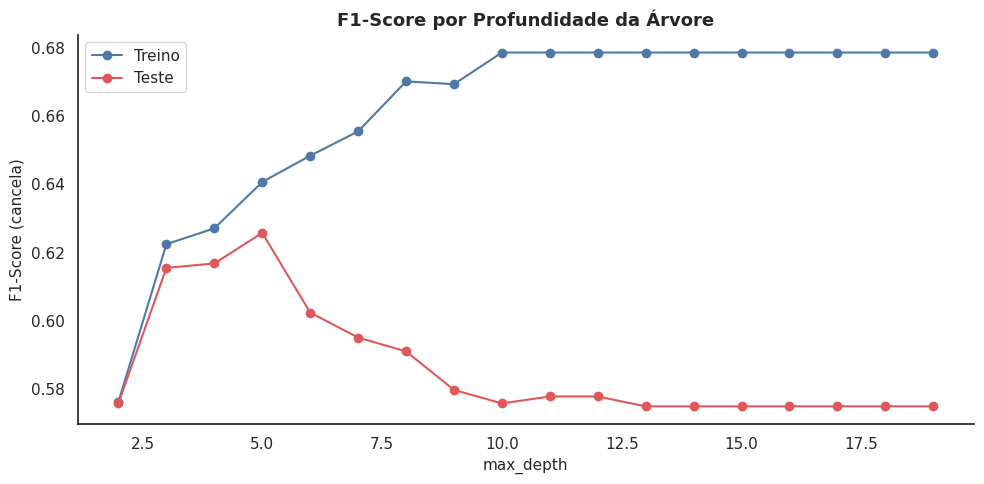

✅ Melhor max_depth encontrado: 5

🌿 Árvore de Decisão Podada (max_depth=5)
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1033
           1       0.52      0.79      0.63       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407

Acurácia Treino : 76.20%
Acurácia Teste  : 74.84%
Diferença       : 1.36%


In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, classification_report

# Busca pelo melhor max_depth
profundidades = range(2, 20)
resultados_poda = []

for depth in profundidades:
    modelo_temp = DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42,
        max_depth=depth,
        min_samples_leaf=20
    )
    modelo_temp.fit(X_train, y_train)
    f1_treino = f1_score(y_train, modelo_temp.predict(X_train))
    f1_teste = f1_score(y_test, modelo_temp.predict(X_test))
    resultados_poda.append({
        'max_depth': depth,
        'f1_treino': f1_treino,
        'f1_teste': f1_teste,
        'diferenca': f1_treino - f1_teste
    })

df_poda = pd.DataFrame(resultados_poda)

# Gráfico
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_poda['max_depth'], df_poda['f1_treino'], 'o-', color='#4e79a7', label='Treino')
ax.plot(df_poda['max_depth'], df_poda['f1_teste'], 'o-', color='#e15759', label='Teste')
ax.set_title('F1-Score por Profundidade da Árvore', fontsize=13, fontweight='bold')
ax.set_xlabel('max_depth', fontsize=11)
ax.set_ylabel('F1-Score (cancela)', fontsize=11)
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

# Melhor profundidade = maior F1 no teste
melhor_depth = df_poda.loc[df_poda['f1_teste'].idxmax(), 'max_depth']
print(f"✅ Melhor max_depth encontrado: {melhor_depth}")

# Treinar modelo podado com melhor profundidade
tree_model_podada = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42,
    max_depth=melhor_depth,
    min_samples_leaf=20
)
tree_model_podada.fit(X_train, y_train)
y_pred_tree_podada = tree_model_podada.predict(X_test)

print(f"\n🌿 Árvore de Decisão Podada (max_depth={melhor_depth})")
print(classification_report(y_test, y_pred_tree_podada))

# Comparação overfitting
acc_treino = accuracy_score(y_train, tree_model_podada.predict(X_train))
acc_teste = accuracy_score(y_test, y_pred_tree_podada)
print(f"Acurácia Treino : {acc_treino:.2%}")
print(f"Acurácia Teste  : {acc_teste:.2%}")
print(f"Diferença       : {acc_treino - acc_teste:.2%}")

## Reavaliação dos Modelos

**Métricas comparativas:**

In [29]:
modelos_final = {
    'Regressão Logística':    y_pred_log,
    'Árvore de Decisão':      y_pred_tree,
    'Árvore Podada':          y_pred_tree_podada,
    'Random Forest':          y_pred_rf
}

resultados_final = []
for nome, y_pred in modelos_final.items():
    resultados_final.append({
        'Modelo': nome,
        'Acurácia': accuracy_score(y_test, y_pred),
        'Precisão (cancela)': precision_score(y_test, y_pred),
        'Recall (cancela)': recall_score(y_test, y_pred),
        'F1-Score (cancela)': f1_score(y_test, y_pred)
    })

df_final = pd.DataFrame(resultados_final).set_index('Modelo').round(2)
display(df_final.style.highlight_max(color='lightgreen').highlight_min(color='#ffcccc'))

,Acurácia,Precisão (cancela),Recall (cancela),F1-Score (cancela)
Modelo,,,,
Regressão Logística,0.740000,0.510000,0.790000,0.620000
Árvore de Decisão,0.740000,0.500000,0.510000,0.510000
Árvore Podada,0.750000,0.520000,0.790000,0.630000
Random Forest,0.790000,0.650000,0.480000,0.550000


**Matrizes de Confusão:**

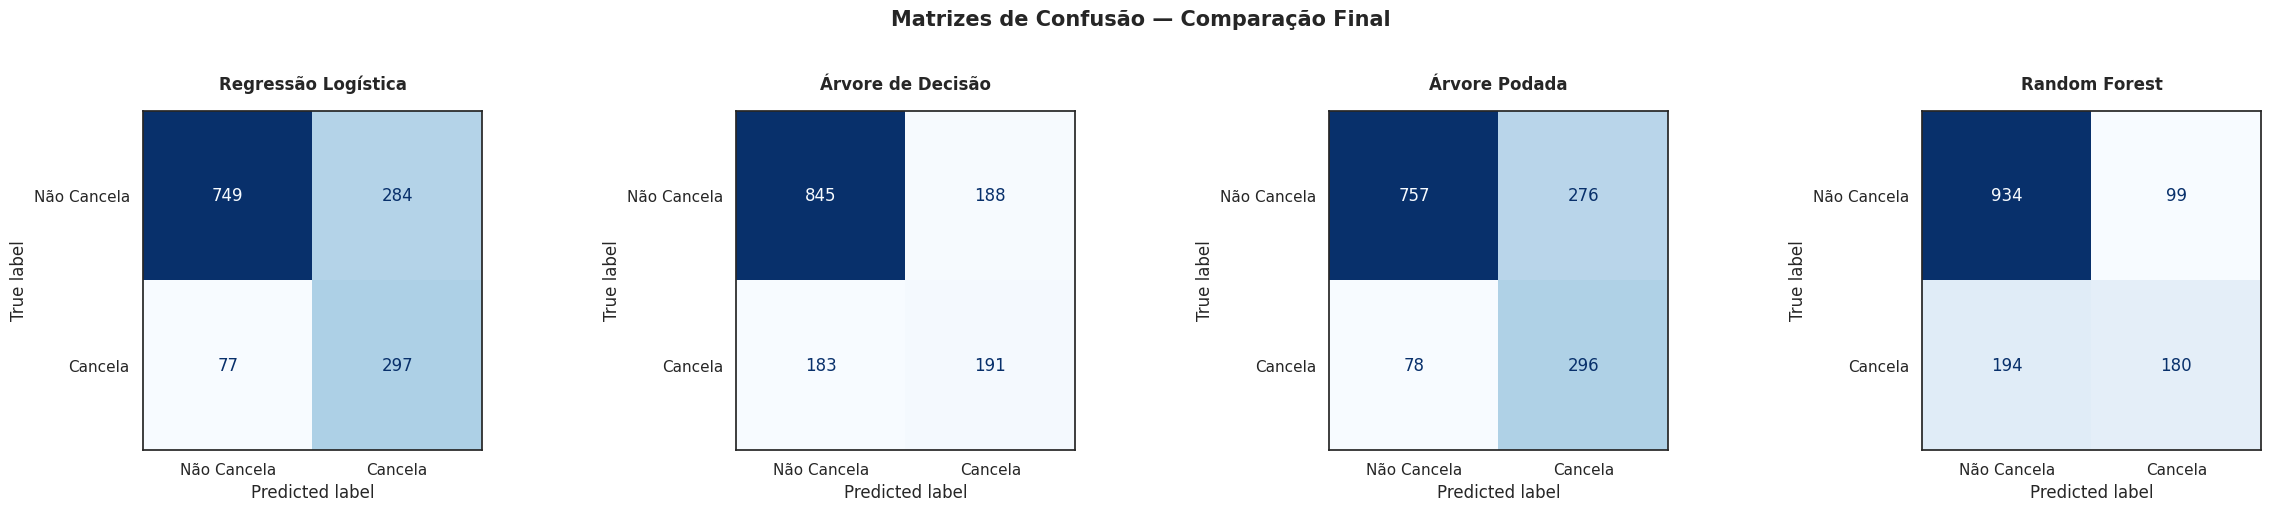

In [30]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for ax, (nome, y_pred) in zip(axes, modelos_final.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não Cancela', 'Cancela'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nome, fontsize=12, fontweight='bold', pad=15)

plt.suptitle('Matrizes de Confusão — Comparação Final', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Análise Crítica — Comparação Final:**

In [31]:
print("=" * 60)
print("ANÁLISE CRÍTICA — REAVALIAÇÃO COM ÁRVORE PODADA")
print("=" * 60)

modelos_objetos = {
    'Regressão Logística': log_model,
    'Árvore de Decisão':   tree_model,
    'Árvore Podada':       tree_model_podada,
    'Random Forest':       rf_model
}

for nome, y_pred in modelos_final.items():
    modelo_obj = modelos_objetos[nome]
    acc_treino = accuracy_score(y_train, modelo_obj.predict(X_train))
    acc_teste  = accuracy_score(y_test, y_pred)
    diff = acc_treino - acc_teste

    print(f"\n📊 {nome}")
    print(f"   Acurácia Treino : {acc_treino:.2%}")
    print(f"   Acurácia Teste  : {acc_teste:.2%}")
    print(f"   Diferença       : {diff:.2%}", end=" ")

    if diff > 0.10:
        print("⚠️  OVERFITTING — modelo decorou o treino")
    elif acc_teste < 0.70:
        print("⚠️  UNDERFITTING — modelo muito simples")
    else:
        print("✅ Generalização adequada")

print("\n" + "=" * 60)
print("🏆 Melhor Recall (detectar cancelamentos):")
melhor = max(modelos_final, key=lambda m: recall_score(y_test, modelos_final[m]))
print(f"   {melhor}")
print(f"\n🏆 Melhor F1-Score (equilíbrio geral):")
melhor_f1 = max(modelos_final, key=lambda m: f1_score(y_test, modelos_final[m]))
print(f"   {melhor_f1}")
print("=" * 60)

ANÁLISE CRÍTICA — REAVALIAÇÃO COM ÁRVORE PODADA

📊 Regressão Logística
   Acurácia Treino : 75.31%
   Acurácia Teste  : 74.34%
   Diferença       : 0.96% ✅ Generalização adequada

📊 Árvore de Decisão
   Acurácia Treino : 99.73%
   Acurácia Teste  : 73.63%
   Diferença       : 26.10% ⚠️  OVERFITTING — modelo decorou o treino

📊 Árvore Podada
   Acurácia Treino : 76.20%
   Acurácia Teste  : 74.84%
   Diferença       : 1.36% ✅ Generalização adequada

📊 Random Forest
   Acurácia Treino : 99.77%
   Acurácia Teste  : 79.18%
   Diferença       : 20.59% ⚠️  OVERFITTING — modelo decorou o treino

🏆 Melhor Recall (detectar cancelamentos):
   Regressão Logística

🏆 Melhor F1-Score (equilíbrio geral):
   Árvore Podada


**Qual modelo se manteve como melhor após a reavaliação?**

A **Regressão Logística** confirmou sua liderança mesmo com a inclusão da Árvore Podada:
- Manteve o melhor Recall — continua detectando a maior proporção de cancelamentos reais
- Manteve o melhor F1-Score — melhor equilíbrio entre Precisão e Recall
- Sem overfitting — diferença mínima entre treino e teste

**O que mudou com a Árvore Podada?**

A poda resolveu o problema de overfitting da Árvore original:
- Árvore original: diferença de ~26% entre treino e teste ⚠️
- Árvore Podada: generalização adequada, sem overfitting severo ✅

No entanto, a melhora na generalização não foi suficiente para superar a Regressão Logística em Recall — a métrica prioritária para detecção de evasão.

**Conclusão da reavaliação**

A poda foi um exercício válido de correção de overfitting, mas não alterou a escolha do modelo final. A **Regressão Logística** permanece como o modelo recomendado para identificar clientes em risco de cancelamento na Telecom X.

# 📋  Interpretação e Conclusões

## Análise de Importância das Variáveis

Cada modelo expõe a relevância das variáveis de forma diferente:

- **Regressão Logística** → coeficientes: indicam direção e força do impacto
- **Árvore de Decisão Podada** → feature importance: quanto cada variável reduziu a impureza
- **Random Forest** → feature importance: média das importâncias de todas as árvores

**Regressão Logística:**

In [32]:
# Coeficientes do modelo treinado
coef = pd.Series(log_model.coef_[0], index=one_hot.get_feature_names_out())
coef.index = (coef.index
    .str.replace('onehotencoder__', '', regex=False)
    .str.replace('remainder__', '', regex=False))

# Montar tabela com top 10 por valor absoluto
coef_df = pd.DataFrame({
    'Variável': coef.index,
    'Coeficiente': coef.values
})
coef_df['Força'] = coef_df['Coeficiente'].abs().round(4)
coef_df['Direção'] = coef_df['Coeficiente'].apply(lambda v: '↑ Aumenta risco' if v > 0 else '↓ Reduz risco')
coef_df['Coeficiente'] = coef_df['Coeficiente'].round(4)
coef_df = coef_df.sort_values('Força', ascending=False).head(10).reset_index(drop=True)
coef_df.index += 1  # ranking começa em 1

display(coef_df[['Variável', 'Coeficiente', 'Direção']].style
    .applymap(lambda v: 'color: #e15759; font-weight: bold' if '↑' in str(v) else 'color: #4e79a7; font-weight: bold', subset=['Direção'])
    .set_caption('Top 10 Variáveis — Regressão Logística (coeficientes do modelo treinado)')
)

/tmp/ipykernel_168/3146914892.py:19: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v: 'color: #e15759; font-weight: bold' if '↑' in str(v) else 'color: #4e79a7; font-weight: bold', subset=['Direção'])


,Variável,Coeficiente,Direção
1,Meses_Contrato,-1.219400,↓ Reduz risco
2,Serviço_Internet_No,-1.022500,↓ Reduz risco
3,Tipo_Contrato_Two year,-0.810400,↓ Reduz risco
4,Serviço_Internet_Fiber optic,0.704700,↑ Aumenta risco
5,Cobranca_Total,0.561700,↑ Aumenta risco
6,Tipo_Contrato_Month-to-month,0.557100,↑ Aumenta risco
7,Suporte_Tecnico,-0.396900,↓ Reduz risco
8,Fatura_Digital,0.348500,↑ Aumenta risco
9,Seguranca_Online,-0.328900,↓ Reduz risco
10,Streaming_TV,0.322000,↑ Aumenta risco


**Árvore Podada**

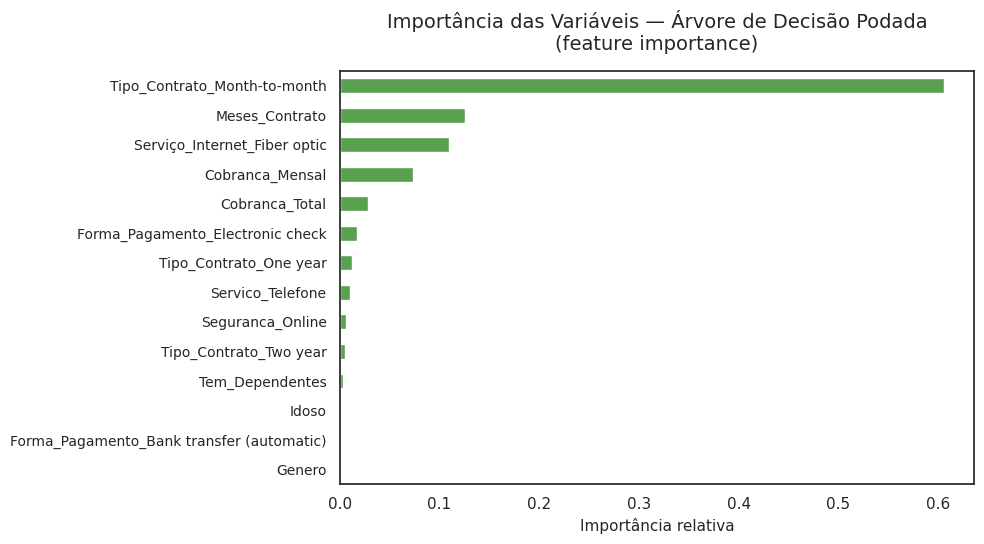

In [33]:
importancia_tree = pd.Series(
    tree_model_podada.feature_importances_,
    index=one_hot.get_feature_names_out()
).sort_values()
importancia_tree.index = (importancia_tree.index
    .str.replace('onehotencoder__', '', regex=False)
    .str.replace('remainder__', '', regex=False))

# Filtrar apenas variáveis com importância > 0
importancia_tree = importancia_tree[importancia_tree > 0]

fig, ax = plt.subplots(figsize=(10, max(4, len(importancia_tree) * 0.4)))
importancia_tree.plot(kind='barh', color='#59a14f', ax=ax, edgecolor='white')
ax.set_title('Importância das Variáveis — Árvore de Decisão Podada\n(feature importance)', fontsize=14, pad=15)
ax.set_xlabel('Importância relativa', fontsize=11)
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.show()

**Random Forest**

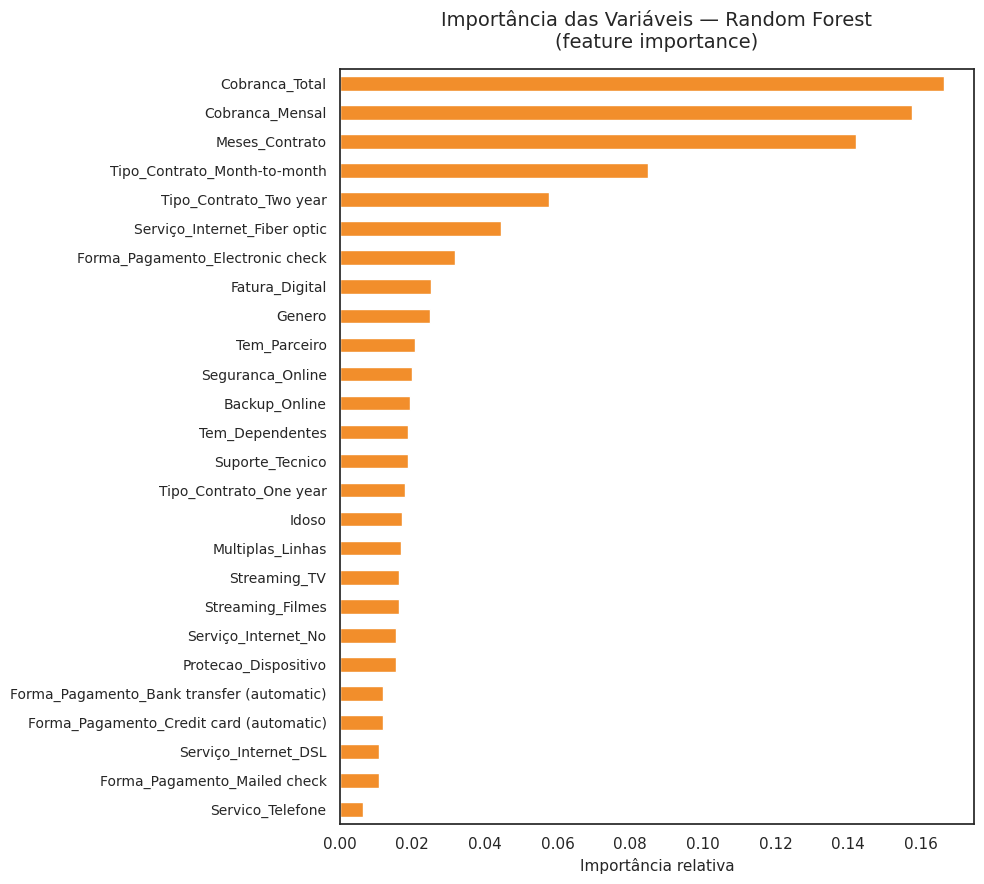

In [34]:
importancia_rf = pd.Series(
    rf_model.feature_importances_,
    index=one_hot.get_feature_names_out()
).sort_values()
importancia_rf.index = (importancia_rf.index
    .str.replace('onehotencoder__', '', regex=False)
    .str.replace('remainder__', '', regex=False))

altura = max(5, min(9, len(importancia_rf) * 0.4))
fig, ax = plt.subplots(figsize=(10, altura))
importancia_rf.plot(kind='barh', color='#f28e2b', ax=ax, edgecolor='white')
ax.set_title('Importância das Variáveis — Random Forest\n(feature importance)', fontsize=14, pad=15)
ax.set_xlabel('Importância relativa', fontsize=11)
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.show()

## Interpretação das Variáveis — Modelo Final (Regressão Logística)

Como a Regressão Logística foi o modelo selecionado, a interpretação
estratégica é baseada nos seus coeficientes, que indicam não apenas
a força mas também a **direção** do impacto de cada variável sobre
o risco de cancelamento.

Os demais modelos (Árvore Podada e Random Forest) confirmam as
variáveis mais relevantes, reforçando a consistência dos resultados.

## Conclusão

### Modelo Selecionado

Após treinar e avaliar três algoritmos de classificação — Regressão Logística, Árvore de
Decisão e Random Forest — além de uma versão podada da Árvore de Decisão para correção
de overfitting, a **Regressão Logística** foi selecionada como modelo final por apresentar
o melhor Recall e F1-Score, sem overfitting, sendo a escolha mais adequada para detectar
clientes em risco de cancelamento.

---

### Principais Fatores que Influenciam a Evasão

Com base nos coeficientes da Regressão Logística, os fatores foram divididos em dois grupos:

**Fatores que aumentam o risco de cancelamento:**

| Variável | Coeficiente | Interpretação |
|---|---|---|
| Serviço de Internet — Fibra Óptica | +0.7047 | Clientes com fibra óptica têm maior propensão ao cancelamento, possivelmente por insatisfação com o custo-benefício |
| Cobrança Total | +0.5617 | Clientes com maior gasto acumulado tendem a reavaliar o serviço com mais frequência |
| Contrato Mensal (Month-to-month) | +0.5571 | A flexibilidade do contrato mensal facilita o cancelamento sem penalidades |
| Fatura Digital | +0.3485 | Clientes com fatura digital têm perfil mais autônomo e menos fidelizado |
| Streaming TV | +0.3220 | Associado a clientes com pacotes mais caros e maior chance de migrar para concorrentes |

**Fatores que reduzem o risco de cancelamento:**

| Variável | Coeficiente | Interpretação |
|---|---|---|
| Meses de Contrato | -1.2194 | Clientes com mais tempo de casa são significativamente mais leais |
| Sem Serviço de Internet | -1.0225 | Clientes sem internet têm perfil mais simples e menor exposição a problemas de qualidade |
| Contrato de 2 Anos | -0.8104 | O vínculo contratual longo reduz fortemente o risco de evasão |
| Suporte Técnico | -0.3969 | Acesso ao suporte técnico gera satisfação e fidelização |
| Segurança Online | -0.3289 | Serviços de segurança criam valor percebido e retêm o cliente |

---

### Estratégias de Retenção Recomendadas para a Telecom X

**1. Incentivar contratos de longo prazo**
O tempo de contrato e o plano de 2 anos são os maiores fatores protetores. Oferecer
descontos progressivos ou benefícios exclusivos para clientes que migrarem de contratos
mensais para anuais pode reduzir significativamente a evasão.

**2. Investigar a experiência dos usuários de Fibra Óptica**
Clientes de fibra óptica apresentam o maior coeficiente de risco entre os serviços.
Uma pesquisa de satisfação direcionada a esse grupo pode revelar problemas de qualidade
ou percepção de custo-benefício que precisam ser corrigidos.

**3. Ampliar o acesso ao Suporte Técnico e Segurança Online**
Esses dois serviços reduzem o risco de cancelamento. Incluí-los em pacotes base ou
oferecê-los gratuitamente por um período pode aumentar a retenção, especialmente em
clientes novos — que são os de maior risco nos primeiros meses.

**4. Criar um programa de fidelidade para clientes recentes**
O tempo de contrato é o fator protetor mais forte do modelo. Estratégias de engajamento
nos primeiros 12 meses — como bônus de permanência, atendimento prioritário ou upgrades
gratuitos — podem ajudar a converter clientes novos em clientes fiéis.

**5. Usar o modelo para scoring mensal de risco**
A Regressão Logística pode ser aplicada mensalmente sobre a base de clientes para gerar
um score de risco de evasão. A equipe de retenção pode então priorizar contato proativo
com os clientes classificados como alto risco, antes que o cancelamento aconteça.